### Option pricing with Binomial tree model
This pricing strategy applies to any option with fixed `u`, `d`, `r` over any number of `nSteps` in a binomial tree model

In [13]:
import math, scipy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [32]:
class AmericanPutPricing:
    def __init__(self, S0, X, d, rf, u, nSteps):
        self.S0 = S0         # Underlying asset price at stipulation
        self.X = X           # Strike price
        self.d = d           # Asset pricing down movement
        self.rf = rf         # Risk-free asset interest rate
        self.u = u           # Asset pricing up movement
        self.nSteps = nSteps # Number of steps in binomial tree

        self.p_star = self.calculate_risk_neutral_prob()
        self.q = self.calculate_q()
        self.m = self.calculate_m()

    def calculate_risk_neutral_prob(self):
        return (self.rf - self.d) / (self.u - self.d)

    def calculate_q(self):
        return self.calculate_risk_neutral_prob() * (1 + self.u) / (1 + self.rf)
    
    def calculate_m(self):
        num = np.log(self.X / self.S0 / (1 + self.d)**self.nSteps)
        den = np.log((1 + self.u) / (1 + self.d))
        return int(math.floor(num / den) + 1)
    
    def build_empty_trees(self):
        self.asset_price_tree = []
        self.option_price_tree = []
        self.exercise_price_tree = []
        self.continuation_value_tree = []
        self.exercise_logic_tree = []

        for t in range(self.nSteps + 1):
            # build a structure such that array[i][j] identifies node i with j up movements
            self.asset_price_tree.append([None] * (t + 1))
            self.option_price_tree.append([None] * (t + 1))
            self.exercise_logic_tree.append([None] * (t + 1))
            self.exercise_price_tree.append([None] * (t + 1))
            self.continuation_value_tree.append([None] * (t + 1))

    def asset_price_ij(self, i, j):
        """Asset price at node i,j"""
        return self.S0 * (1 + self.u)**j * (1 + self.d)**(i-j)

    def fill_trees(self):
        self.build_empty_trees()

        def calculate_node(i, j):
            asset_price = self.asset_price_ij(i, j)
            exercise_price = max(self.X - asset_price, 0) # put option
            self.asset_price_tree[i][j] = asset_price
            self.exercise_price_tree[i][j] = exercise_price

            # Terminal node
            if i == self.nSteps:
                option_price = exercise_price
                self.option_price_tree[i][j] = option_price
                self.continuation_value_tree[i][j] = None
                self.exercise_price_tree[i][j] = False
                return option_price

            # Recursive continuation value
            up_value = calculate_node(i + 1, j + 1)
            down_value = calculate_node(i + 1, j)
            continuation_value = (self.p_star * up_value + (1 - self.p_star) * down_value) / (1 + self.rf)

            option_price = max(exercise_price, continuation_value)

            self.option_price_tree[i][j] = option_price
            self.continuation_value_tree[i][j] = continuation_value
            self.exercise_price_tree[i][j] = exercise_price > continuation_value

            return option_price

        return calculate_node(0, 0)
    

    def evaluate_trees(self, decimals=2):
        self.fill_trees()

        print(f"Risk-neutral probability p* = {self.p_star:.{decimals}f}")
        print(f"American put price = {self.option_price_tree[0][0]:.{decimals}f}")
        print()

        for i in range(self.nSteps + 1):
            print(f"Step {i}")

            for j in range(i + 1):
                asset_price = self.asset_price_tree[i][j]
                option_price = self.option_price_tree[i][j]
                exercise_price = self.exercise_price_tree[i][j]
                continuation_value = self.continuation_value_tree[i][j]

                if i == self.nSteps:
                    decision = "PAYOFF"
                    continuation_display = "-"
                else:
                    decision = "EXERCISE" if self.exercise_price_tree[i][j] else "HOLD"
                    continuation_display = f"{continuation_value:.{decimals}f}"

                print(
                    f"  Node ({i},{j}) | "
                    f"S = {asset_price:.{decimals}f} | "
                    f"P = {option_price:.{decimals}f} | "
                    f"Exercise = {exercise_price:.{decimals}f} | "
                    f"Continue = {continuation_display} | "
                    f"{decision}"
                )

            print()


    def plot_tree(
        self,
        kind="both",
        decimals=2,
        figsize=None,
        show_legend=True,
        title="American Put Binomial Tree"
    ):

        if figsize is None:
            figsize = (max(10, 2.2 * self.nSteps), max(6, 1.4 * self.nSteps))

        fig, ax = plt.subplots(figsize=figsize)

        colors = {
            "continue": "#E8F1FF",
            "exercise": "#FFE5E5",
            "terminal": "#F2F2F2",
            "edge": "#9AA4B2",
            "node_edge": "#2E4057",
            "exercise_edge": "#C0392B",
            "text": "#1F2933"
        }

        positions = {}

        for i in range(self.nSteps + 1):
            for j in range(i + 1):
                x = i
                y = 2 * j - i
                positions[(i, j)] = (x, y)

        # Draw branches first so nodes sit on top
        for i in range(self.nSteps):
            for j in range(i + 1):
                x, y = positions[(i, j)]
                x_down, y_down = positions[(i + 1, j)]
                x_up, y_up = positions[(i + 1, j + 1)]

                ax.plot(
                    [x, x_up],
                    [y, y_up],
                    color=colors["edge"],
                    linewidth=1.4,
                    alpha=0.75,
                    zorder=1
                )
                ax.plot(
                    [x, x_down],
                    [y, y_down],
                    color=colors["edge"],
                    linewidth=1.4,
                    alpha=0.75,
                    zorder=1
                )

        node_width = 0.85
        node_height = 0.62
        font_size = max(6, min(9, 11 - 0.45 * self.nSteps))

        for i in range(self.nSteps + 1):
            for j in range(i + 1):
                x, y = positions[(i, j)]
                asset_price = self.asset_price_tree[i][j]
                option_price = self.option_price_tree[i][j]
                exercised = self.exercise_price_tree[i][j]
                is_terminal = i == self.nSteps

                if is_terminal:
                    face_color = colors["terminal"]
                    edge_color = colors["node_edge"]
                    linewidth = 1.3
                elif exercised:
                    face_color = colors["exercise"]
                    edge_color = colors["exercise_edge"]
                    linewidth = 2.2
                else:
                    face_color = colors["continue"]
                    edge_color = colors["node_edge"]
                    linewidth = 1.3

                box = patches.FancyBboxPatch(
                    (x - node_width / 2, y - node_height / 2),
                    node_width,
                    node_height,
                    boxstyle="round,pad=0.08,rounding_size=0.08",
                    linewidth=linewidth,
                    edgecolor=edge_color,
                    facecolor=face_color,
                    zorder=3
                )

                ax.add_patch(box)

                if kind == "stock":
                    label = f"S={asset_price:,.{decimals}f}"
                elif kind == "option":
                    label = f"P={option_price:,.{decimals}f}"
                else:
                    label = (
                        f"S={asset_price:,.{decimals}f}\n"
                        f"P={option_price:,.{decimals}f}"
                    )

                if is_terminal:
                    label += "\nPAYOFF"
                elif exercised:
                    label += "\nEXERCISE"
                else:
                    label += "\nHOLD"

                ax.text(
                    x,
                    y,
                    label,
                    ha="center",
                    va="center",
                    fontsize=font_size,
                    color=colors["text"],
                    zorder=4
                )

        price = self.option_price_tree[0][0]

        info = (
            f"Price = {price:.{decimals}f}\n"
            f"p* = {self.p_star:.{decimals}f}\n"
            f"u = {self.u:.{decimals}f}, "
            f"d = {self.d:.{decimals}f}, "
            f"rf = {self.rf:.{decimals}f}"
        )

        ax.text(
            0.02,
            0.98,
            info,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            bbox=dict(
                boxstyle="round,pad=0.45",
                facecolor="white",
                edgecolor="#D0D7DE",
                alpha=0.95
            )
        )

        if show_legend:
            legend_items = [
                patches.Patch(
                    facecolor=colors["continue"],
                    edgecolor=colors["node_edge"],
                    label="Hold / continue"
                ),
                patches.Patch(
                    facecolor=colors["exercise"],
                    edgecolor=colors["exercise_edge"],
                    label="Early exercise"
                ),
                patches.Patch(
                    facecolor=colors["terminal"],
                    edgecolor=colors["node_edge"],
                    label="Terminal payoff"
                )
            ]

            ax.legend(
                handles=legend_items,
                loc="best",
                bbox_to_anchor=(0.5, -0.08),
                ncol=3,
                frameon=False
            )

        ys = [y for _, y in positions.values()]

        ax.set_title(title, fontsize=15, pad=18)
        ax.set_xlim(-0.8, self.nSteps + 0.8)
        ax.set_ylim(min(ys) - 1, max(ys) + 1)
        ax.set_xlabel("Time step")
        ax.set_xticks(range(self.nSteps + 1))
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.grid(axis="x", alpha=0.15)

        plt.tight_layout()
        plt.show()

    def plot_stock_tree(self, **kwargs):
        self.plot_tree(kind="stock", title="Stock Price Tree", **kwargs)

    def plot_option_price_tree(self, **kwargs):
        self.plot_tree(kind="option", title="American Put Value Tree", **kwargs)


Risk-neutral probability p* = 0.53
American put price = 2.52

Step 0
  Node (0,0) | S = 60.00 | P = 2.52 | Exercise = 0.00 | Continue = 2.52 | HOLD

Step 1
  Node (1,0) | S = 57.00 | P = 5.00 | Exercise = 1.00 | Continue = 4.13 | EXERCISE
  Node (1,1) | S = 66.00 | P = 0.50 | Exercise = 0.00 | Continue = 0.50 | HOLD

Step 2
  Node (2,0) | S = 54.15 | P = 7.85 | Exercise = 1.00 | Continue = 6.04 | EXERCISE
  Node (2,1) | S = 62.70 | P = 1.10 | Exercise = 0.00 | Continue = 1.10 | HOLD
  Node (2,2) | S = 72.60 | P = 0.00 | Exercise = 0.00 | Continue = 0.00 | HOLD

Step 3
  Node (3,0) | S = 51.44 | P = 10.56 | Exercise = 0.00 | Continue = - | PAYOFF
  Node (3,1) | S = 59.56 | P = 2.44 | Exercise = 0.00 | Continue = - | PAYOFF
  Node (3,2) | S = 68.97 | P = 0.00 | Exercise = 0.00 | Continue = - | PAYOFF
  Node (3,3) | S = 79.86 | P = 0.00 | Exercise = 0.00 | Continue = - | PAYOFF



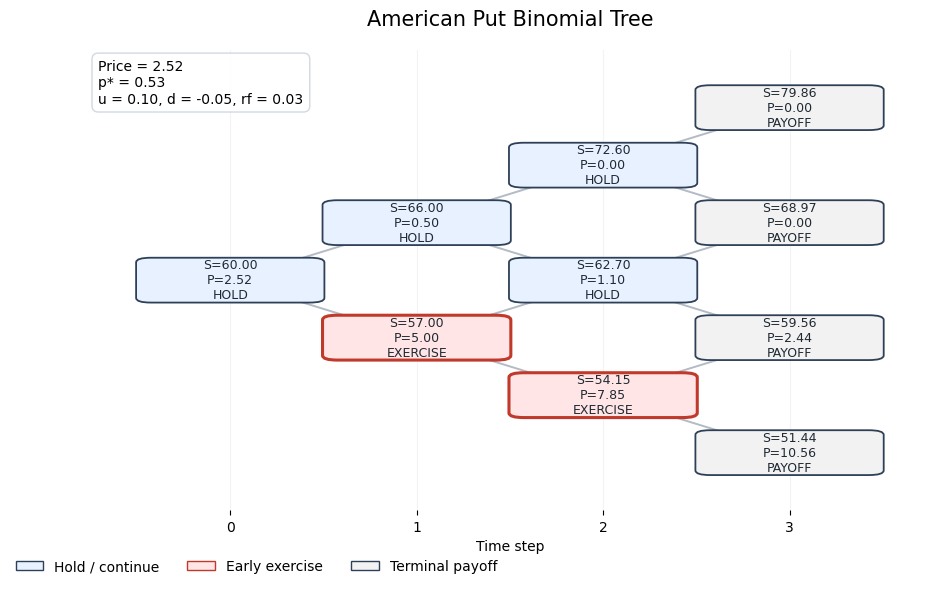

In [34]:
tree = AmericanPutPricing(
    S0=60,
    X=62,
    d=-0.05,
    rf=0.03,
    u=0.1,
    nSteps=3,
)

tree.evaluate_trees()
tree.plot_tree(kind="both")